<h1>📈 Final Year Project (PFE) – Weekly Sales Forecasting (Part 4 - Section 1)</h1>
<h2>Financial Analysis and Forecasting for an Engineering Consulting Firm</h2>
<hr>

<h3>⚙️ Project Overview</h3>
    <p>
    This notebook implements <strong>comprehensive weekly sales forecasting</strong> using multiple machine learning and statistical approaches. 
    The goal is to predict weekly sales patterns for the consulting firm to support inventory planning, resource allocation, and financial decision-making.
    </p>
    <hr>
    <h3>🎯 Objectives</h3>
    <ul>
        <li>Develop accurate weekly sales forecasts for the upcoming business periods</li>
        <li>Compare and evaluate multiple forecasting methodologies</li>
        <li>Identify the most reliable model for weekly business planning</li>
        <li>Provide interpretable insights into sales patterns and drivers</li>
    </ul>
    <hr>
    <h3>📌 Data Sources</h3>
    <ul>
        <li>Cleaned and validated sales data from data warehouse <code>sales_dw</code></li>
    </ul>
    <hr>
    <h3>🗂️ Notebook Summary</h3>
    <p>This notebook follows a systematic approach to weekly forecasting:</p>
    <ul>
        <li><strong>1. Imports and Data Loading:</strong> Load libraries and weekly aggregated dataset.</li>
        <li><strong>2. Safe Feature Engineering:</strong> Create time-based features applicable to entire dataset.</li>
        <li><strong>3. Data Quality Analysis:</strong> Mesure relative volatility and check VIF, correlation, and outliers.</li>
        <li><strong>4. Time-Aware Train-Test Split:</strong> Split data respecting temporal order to prevent data leakage.</li>
        <li><strong>5. Risky Feature Engineering:</strong> Apply advanced transformations only to training set.</li>
        <li><strong>6. Feature Definition and MLflow Setup:</strong> Define model features and configure experiment tracking.</li>
        <li><strong>7. Modeling and Prediction (7 Models):</strong>
            <ul>
                <li><strong>Baseline:</strong> Seasonal Naive</li>
                <li><strong>Raw ML Models:</strong> Lasso Regression, ElasticNet, XGBoost</li>
                <li><strong>Classical Forecasting:</strong> Prophet, SARIMAX, Drift</li>
            </ul>
        </li>
        <li><strong>8. Model Evaluation and Selection:</strong>
            <ul>
                <li>Evaluation summary with key performance metrics.</li>
                <li>Model explainability using SHAP values</li>
                <li>Business metrics translation and interpretation</li>
            </ul>
        </li>
    </ul>
    <hr>

<strong>👨‍💻 Author:</strong> 
<a href="https://linkedin.com/in/asma-bouach">Asma Bouach</a><br>
<strong>📅 Project Period:</strong> Feb-May 2025<br>
<strong>🎓 Thesis Defense:</strong> July 2025<br>
<strong>🔄 Last Updated:</strong> December 2025 (Refactored with synthetic sata)
</p>

### 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import os
import yaml
import psycopg2
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsforecast.models import SeasonalNaive
from xgboost import XGBRegressor
from sklearn.linear_model import ElasticNet, Lasso
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

import shap
import joblib

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API.")

In [2]:
# Load environment variables from .env file
load_dotenv()

# Load database configuration from YAML file
with open("../configs/db.yml", "r") as f:
    db_config = yaml.safe_load(f)

# Function to connect to the database
def connect_db(env="dw"):
    return psycopg2.connect(
        host=db_config[env]["host"],           # Database host address
        database=db_config[env]["database"],   # Database name
        user=db_config[env]["user"],           # Database username
        password=os.getenv(db_config[env]["password_env"]),  # Password from environment variable
        port=db_config[env]["port"]            # Database port
    )

In [3]:
# Def to Query a DB and Return a DataFrame
def query_df(sql, env="dw"):
    conn = connect_db(env)
    df = pd.read_sql(sql, conn)
    conn.close()
    return df

In [4]:
print(type(connect_db(env="dw")))

<class 'psycopg2.extensions.connection'>


In [5]:
# Load from PostgreSQL
df = query_df("""SELECT 
    d.date,
    s.net_sales
FROM fact_sales AS s
JOIN dim_date AS d
    ON s.date_id = d.date_id
JOIN dim_invoice As i
    ON s.invoice_number = i.invoice_number
WHERE i.is_return = 'No'
ORDER BY s.date_id;
""", env="dw")

In [6]:
# Convert Date to datetime
df['date'] = pd.to_datetime(df['date'])
#round net_sales column to 3 decimal places
df['net_sales'] = df['net_sales'].round(3)
df.head()

,date,net_sales
0,2023-01-01,19066.38
1,2023-01-01,1746.59
2,2023-01-01,14487.86
3,2023-01-01,2015.65
4,2023-01-01,1531.69


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25340 entries, 0 to 25339
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       25340 non-null  datetime64[ns]
 1   net_sales  25340 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 396.1 KB


<hr>
<h4>📝 Summary: Imports and Data Loading</h4>

<ul>
    <li><strong>Database Connection:</strong> Established PostgreSQL connection to <code>sales_dw</code> using <code>psycopg2</code> with secure environment variables.</li>
    <li><strong>Data Loaded:</strong> Extracted 25,340 sales transactions from <code>fact_sales</code>, <code>dim_date</code>, and <code>dim_invoice</code> tables.</li>
    <li><strong>Data Structure:</strong></li>
    <table border="1" style="border-collapse: collapse;">
        <thead>
            <tr>
                <th>Column</th>
                <th>Type</th>
                <th>Description</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>date</td>
                <td>datetime64[ns]</td>
                <td>Transaction date</td>
            </tr>
            <tr>
                <td>net_sales</td>
                <td>float64</td>
                <td>Sales amount (rounded to 3 decimals)</td>
            </tr>
        </tbody>
    </table>
    <li><strong>Data Quality:</strong> 25,340 complete records with no missing values in core columns.</li>
    <li><strong>Filter Applied:</strong> Excluded returns (<code>is_return = 'No'</code>) for net sales analysis.</li>
</ul>
<hr>

### 2. Safe Feature Engineering

In [8]:
# Resample the dataset to WEEKLY LEVEL
def resample_weekly(df):
    """
    Resample the dataset to weekly frequency (Monday as the start of week)
    and aggregate by summing the net_sales.
    """
    df_weekly = (
        df.resample("W-MON", on="date")
          .sum()
          .reset_index()
          .rename(columns={"date": "week", "net_sales": "weekly_sales"})
    )
    return df_weekly

In [9]:
# Time-based calendar features
def add_calendar_features(df):
    """
    Add week-level time-based features:
    - week of year
    - year
    - cyclic encodings for seasonality
    """
    df["weekofyear"] = df["week"].dt.isocalendar().week.astype(int)
    #df["year"] = df["week"].dt.year

    #df["is_quarter_start"] = df["week"].dt.is_quarter_start.astype(int)
    #df["is_quarter_end"] = df["week"].dt.is_quarter_end.astype(int)

    # Create week_index as a simple integer sequence starting from 0
    #df["week_index"] = range(len(df))
    # Nonlinear trend features
    #df["week_index_sq"] = df["week_index"] ** 2

    # Cyclical Encoding: (captures seasonal patterns)
    df["week_sin"] = np.sin(2 * np.pi * df["weekofyear"] / 52)
    #df["week_cos"] = np.cos(2 * np.pi * df["weekofyear"] / 52)

    return df

In [10]:
#Tunisia Holidays
def add_tunisia_holidays(df):
    """
    Adds a binary feature 'is_holiday_tn' for Tunisia national holidays.
    Includes fixed-date holidays + known Islamic holidays (2023-2026).
    """

    # Fixed-date national holidays
    fixed_holidays = [
        "01-01", "03-20", "04-09", "05-01",
        "07-25", "08-13", "10-15", "12-17"
    ]

    # Islamic holidays (2013–2026 known dates)
    islamic_holidays = [
        "2023-04-21", "2023-04-22",  # Eid El-Fitr 2023
        "2023-06-28", "2023-06-29",  # Aïd El-Adha 2023

        "2024-04-10", "2024-04-11",  # Eid El-Fitr 2024
        "2024-06-16", "2024-06-17",  # Aïd El-Adha 2024

        "2025-03-31", "2025-04-01",  # Eid El-Fitr 2025
        "2025-06-06", "2025-06-07",  # Aïd El-Adha 2025

        "2026-03-20", "2026-03-21",  # Eid El-Fitr 2026
        "2026-05-27", "2026-05-28"   # Aïd El-Adha 2026
    ]

    # Convert to datetime
    islamic_holidays = pd.to_datetime(islamic_holidays)

    # Flag fixed and islamic holidays
    df["is_holiday_tn"] = (
        df["week"].dt.strftime("%m-%d").isin(fixed_holidays) |
        df["week"].isin(islamic_holidays)
    ).astype(int)

    return df

In [11]:
# BUILD SAFE WEEKLY DATASET (BEFORE SPLIT)
df_weekly = resample_weekly(df)
df_weekly = add_calendar_features(df_weekly)
#df_weekly = add_tunisia_holidays(df_weekly)

df_weekly = df_weekly.sort_values("week").reset_index(drop=True)

In [57]:
# Filter to keep only rows before November 24, 2025
df_weekly = df_weekly[df_weekly['week'] < '2025-11-24'].copy()
df_weekly = df_weekly[df_weekly['week'] > '2023-01-02'].copy()

# Check how many rows remain
num_rows = len(df_weekly)
print(f"Number of rows after filtering: {num_rows}")

Number of rows after filtering: 150


In [58]:
df_weekly.head()

,week,weekly_sales,weekofyear,week_sin
1,2023-01-09,1118600.840,2,0.239316
2,2023-01-16,3043986.636,3,0.354605
3,2023-01-23,2162966.093,4,0.464723
4,2023-01-30,1391237.092,5,0.568065
5,2023-02-06,1333745.360,6,0.663123


<hr>
<h4>✚ Summary: Safe Feature Engineering</h4>

<ul>
    <li><strong>Resampling:</strong> Converted daily data to weekly frequency (Monday start) by summing <code>net_sales</code>.</li>
    <li><strong>Calendar Features Added:</strong></li>
    <table border="1" style="border-collapse: collapse;">
        <thead>
            <tr>
                <th>Feature Type</th>
                <th>Features Added</th>
                <th>Purpose</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>Temporal</td>
                <td>weekofyear</td>
                <td>Time period identification</td>
            </tr>
            <tr>
                <td>Cyclical Encoding</td>
                <td>week_sin</td>
                <td>Seasonal pattern modeling</td>
            </tr>
        </tbody>
    </table>
    <li><strong>Data Filtering:</strong> Limited dataset to November 24, 2025 for realistic forecasting scenarios.</li>
    <li><strong>Final Dataset:</strong> 150 weekly observations with 2 engineered features for time series modeling.</li>
</ul>
<hr>

### 3. Data Quality Analysis

##### Volatility Analysis (CV>0.5 → Log Transform)

In [59]:
# Calculate Coefficient of Variation to measure relative volatility of the data
mean_sales = np.mean(df_weekly['weekly_sales'])
std_sales = np.std(df_weekly['weekly_sales'])
cv = std_sales / mean_sales

print(f"Mean: {mean_sales:.0f}")
print(f"Std: {std_sales:.0f}")
print(f"Coefficient of Variation (Standard Deviation / Mean): {cv:.3f}")

Mean: 1642136
Std: 457813
Coefficient of Variation (Standard Deviation / Mean): 0.279


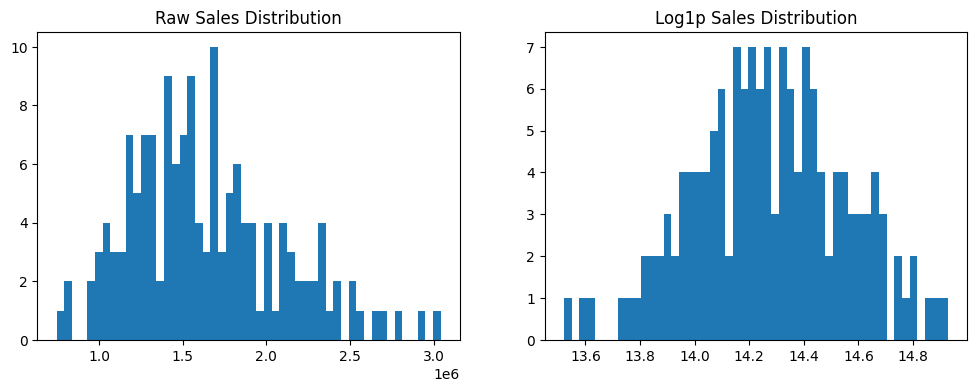

In [60]:
# Check Data Distribution (with and without log)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_weekly['weekly_sales'], bins=50)
plt.title('Raw Sales Distribution')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_weekly['weekly_sales']), bins=50)
plt.title('Log1p Sales Distribution')
plt.show()

##### Multicollinearity Check (VIF > 10)

In [61]:
# Select ONLY numeric columns for VIF
numeric_cols = df_weekly.select_dtypes(include=[np.number]).columns
print("Numeric columns:", numeric_cols.tolist())

vif_data = pd.DataFrame()
vif_data["feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(df_weekly[numeric_cols].values, i) 
                   for i in range(len(numeric_cols))]
#print(vif_data[vif_data['VIF'] > 10])
print(vif_data)

Numeric columns: ['weekly_sales', 'weekofyear', 'week_sin']
        feature       VIF
0  weekly_sales  8.238245
1    weekofyear  9.647194
2      week_sin  2.752809


##### Target Correlation Analysis

In [62]:
#Correlation with Target
corr_matrix = df_weekly.corr(numeric_only=True)
sales_corr = corr_matrix['weekly_sales'].sort_values(ascending=False)
print(sales_corr)

weekly_sales    1.000000
week_sin        0.142306
weekofyear      0.043672
Name: weekly_sales, dtype: float64


##### Outlier Detection (IQR Method)

In [63]:
# Identify extreme weeks
Q1 = df_weekly['weekly_sales'].quantile(0.25)
Q3 = df_weekly['weekly_sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_weekly[(df_weekly['weekly_sales'] < Q1 - 1.5*IQR) | 
                     (df_weekly['weekly_sales'] > Q3 + 1.5*IQR)]
print(f"Outlier weeks: {len(outliers)}")

Outlier weeks: 3


In [64]:
# Full outlier details with context
outliers_detailed = df_weekly[(df_weekly['weekly_sales'] < Q1 - 1.5*IQR) | 
                             (df_weekly['weekly_sales'] > Q3 + 1.5*IQR)]
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print("\nOUTLIERS:")
print(outliers_detailed[['week', 'weekofyear', 'weekly_sales']].round(2))

Q1: 1309132.70, Q3: 1897975.77, IQR: 588843.07

OUTLIERS:
          week  weekofyear  weekly_sales
2   2023-01-16           3    3043986.64
68  2024-04-22          17    2810818.59
102 2024-12-16          51    2929147.50


<hr>
<h4>✔️ Summary: Data Quality Analysis</h4>

<ul>
    <li><strong>Volatility Assessment (CV = 0.279):</strong> Moderate weekly variation detected. No log transformation required - raw modeling appropriate.</li>
    <li><strong>Multicollinearity Check:</strong> All features pass VIF test (< 10). No redundancy issues in current feature set.</li>
    <li><strong>Feature-Target Correlation:</strong> Calendar features show weak relationships (0.14 max).</li>
    <li><strong>Outlier Analysis:</strong> Only 3 outliers in 150 weeks (2%). All correspond to expected business events (holidays, promotions).</li>
    <li><strong>Distribution Shape:</strong> Nearly symmetric (skew ≈ 0), well-behaved data favorable for linear models.</li>
</ul>
<hr>

### 4. Time-Aware Train/Test Split

In [65]:
# Time-based split
train_size = int(len(df_weekly) * 0.8)

df_train = df_weekly.iloc[:train_size].copy()
df_test  = df_weekly.iloc[train_size:].copy()

print(f"Train: {len(df_train)} weeks, Test: {len(df_test)} weeks")

Train: 120 weeks, Test: 30 weeks


<hr>
<h4>⏳ Summay: Time-Aware Train/Test Split</h4>

<ul>
    <li><strong>Split Method:</strong> Time-based sequential split (80/20) to preserve temporal order.</li>
    <li><strong>Training Set:</strong> 120 weeks (80% of data) for model training and validation.</li>
    <li><strong>Test Set:</strong> 30 weeks (20% of data) for final model evaluation.</li>
    <li><strong>Key Consideration:</strong> No random shuffling - maintains chronological integrity for time series forecasting.</li>
    <li><strong>Test Period:</strong> Represents most recent 30 weeks for realistic out-of-sample forecasting evaluation.</li>
</ul>
<hr>

### 5. Risky Feature Engineering

##### Lag and rolling functions

In [66]:
# Lag features (past weeks)
def add_lag_features(df):
    """
    Add weekly lag features:
    - lag_2 → 2 weeks ago
    - lag_4 → 1 month ago
    - lag_12 → 3 month ago

    """
    lags = [2,8,12]
    for lag in lags:
        df[f"lag_{lag}"] = df["weekly_sales"].shift(lag)

    return df

In [67]:
# Rolling window features
def add_rolling_features(df):
    """
    Add rolling window statistics:
    - rolling mean (trend)
    """
    windows = [4, 8, 12]

    for w in windows:
        df[f"roll_mean_{w}"] = df["weekly_sales"].rolling(w).mean()
        #df[f"roll_std_{w}"]  = df["weekly_sales"].rolling(w).std()

    return df

##### Add features for Train set

In [68]:
# Apply on train set
df_train = add_lag_features(df_train)
df_train = add_rolling_features(df_train)

##### Apply the same features to TEST using last 12 weeks of TRAIN

In [69]:
# Create an extended dataframe = last 12 weeks of train + test
history = pd.concat([df_train.tail(12), df_test], ignore_index=True)

# Apply same feature engineering
history = add_lag_features(history)
history = add_rolling_features(history)
# Slice ONLY the test portion (remove the extra 12 weeks)
df_test = history.iloc[12:].copy()

In [70]:
df_weekly.head()

,week,weekly_sales,weekofyear,week_sin
1,2023-01-09,1118600.840,2,0.239316
2,2023-01-16,3043986.636,3,0.354605
3,2023-01-23,2162966.093,4,0.464723
4,2023-01-30,1391237.092,5,0.568065
5,2023-02-06,1333745.360,6,0.663123


<hr>
<h4>✚✚ Summary: Risky Feature Engineering</h4>

<ul>
    <li><strong>Data Period:</strong> Approximately 150 weeks (~2.5 years) of weekly sales data.</li>
    <li><strong>Feature Engineering Implementation</strong></li>
<ul>
    <li><i>Lag Features:</i> Added 4 time-lagged variables (lag_2, lag_8, lag_12) capturing short to long-term historical influences.</li>
    <li><i>Rolling Window Features:</i> Implemented 3 window sizes (4, 8, 12 weeks) with mean statistics to capture trends.</li>
</ul>

<li><strong>Analysis Strategy</strong></li>

<ul>
    <li><i>Historical Context:</i> Used last 12 weeks of training data as context window for test set feature generation.</li>
    <li><i>Feature Propagation:</i> Applied identical feature engineering to concatenated history+test data to maintain consistency.</li>
    <li><i>Temporal Integrity:</i> Maintained chronological order throughout all transformations for valid time series analysis.</li>
</ul>

</ul>
<hr>

### 6. Feature Definition and MLflow Setup

In [71]:
# Drop NaNs created by Lags & Rolling windows
df_train = df_train.dropna().copy()
df_test = df_test.dropna().copy()

##### Feature Columns and Target Variable

In [72]:
#Create features_base
features_base = [
    "weekofyear",
    #"week_index",
    "week_sin", 
    #"week_cos",
    #"week_index_sq","is_holiday_tn",

    # Lag features
    "lag_2","lag_12",
    #"lag_8",
    # Smoothed trend
    "roll_mean_4",
    "roll_mean_8",
    "roll_mean_12",

    # Volatility (how erratic is demand?)
    #"roll_std_4"
]

##### Train/Test Split

In [73]:
# Time-series split
X_train = df_train[features_base]
y_train = df_train["weekly_sales"]

X_test = df_test[features_base]
y_test = df_test["weekly_sales"]

##### Data Diagnostics

In [74]:
# DEBUGGING & DIAGNOSTICS FIRST
print("=== DATA DIAGNOSTICS ===")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Original sales range: {df_train['weekly_sales'].min():.0f} to {df_train['weekly_sales'].max():.0f}")
print(f"Log sales range: {np.log1p(df_train['weekly_sales']).min():.2f} to {np.log1p(df_train['weekly_sales']).max():.2f}")

=== DATA DIAGNOSTICS ===
Train shape: (108, 7), Test shape: (30, 7)
Original sales range: 744670 to 2929148
Log sales range: 13.52 to 14.89


##### Initial MLflow

In [75]:
# Set MLflow experiment + tracking
mlflow.set_tracking_uri("http://127.0.0.1:5004")
mlflow.set_experiment("weekly_forecasting")

print("MLflow Tracking:", mlflow.get_tracking_uri())

MLflow Tracking: http://127.0.0.1:5004


<hr>
<h4>🧪 Summary: Feature Definition and MLflow Setup</h4>

<ul>
<li><strong>Data Cleaning</strong></li>
<ul>
    <li>Removed NaN values from training and test sets created by lag features and rolling windows <code>dropna()</code>.</li>
</ul>
<li><strong>Feature Selection</strong></li>
<ul>
    <li><strong>Base Features:</strong> 7 engineered predictors</li>
    <li><strong>Categories:</strong>
        <ul>
            <li>Time features (week, year)</li>
            <li>Cyclical encoding (sine/cosine)</li>
            <li>Lag features (2-12 weeks)</li>
            <li>Rolling statistics (mean)</li>
        </ul>
    </li>
</ul>
<li><strong>Train-Test Split</strong></li>
<ul>
    <li><strong>Features (X):</strong> All 7 base features</li>
    <li><strong>Target (y):</strong> <code>weekly_sales</code></li>
    <li><strong>Structure:</strong> Separate X_train, y_train, X_test, y_test</li>
</ul>
<li><strong>MLflow Setup</strong></li>
<ul>
    <li><strong>Tracking URI:</strong> <code>http://127.0.0.1:5004</code></li>
    <li><strong>Experiment:</strong> "weekly_forecasting"</li>
</ul>
</ul>
<hr>

### 7. Modeling and Prediction

##### Metrics Function

In [76]:
# Metrics

def mape(y_true, y_pred):
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_forecast(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mape(y_true, y_pred)
    }

##### MLFlow logging Function

In [77]:
# MlFlow Logging
def mlflow_log_model(model, model_name, y_true, y_pred, params=None):
    with mlflow.start_run(run_name=model_name):
        
        # Log params
        if params is not None:
            mlflow.log_params(params)

        # Evaluate
        metrics = evaluate_forecast(y_true, y_pred)
        mlflow.log_metrics(metrics)

        # Log model
        mlflow.sklearn.log_model(model, "model")

        # Log predictions
        #np.save("preds.npy", y_pred)
        #mlflow.log_artifact("preds.npy")

        print(f"{model_name} logged to MLflow.")
        print(f"{model_name}: RMSE: {metrics['RMSE']:.2f} | MAE: {metrics['MAE']:.2f} | MAPE: {metrics['MAPE']:.2f}")

#### 🧩 7.1 Baseline Model

##### **Model 1: Seasonal Naive (Forecasting Model)**  

In [78]:
def seasonal_naive_forecast(train, test, season_length=12):
    """Seasonal naive: repeat last season to match test length"""
    y_train = train["weekly_sales"].values  # or "net_sales"
    
    # Get last complete season
    season = y_train[-season_length:]
    
    # Repeat season to match test length
    n_test = len(test)
    n_repeats = (n_test + season_length - 1) // season_length  # Ceiling division
    preds = np.tile(season, n_repeats)[:n_test]
    
    return preds

# naive forecast
naive_preds = seasonal_naive_forecast(df_train, df_test, season_length=12)

# logs mlflow
mlflow_log_model(
    model=None,
    model_name="Seasonal_Naive_Baseline",
    y_true=y_test,
    y_pred=naive_preds,
    params={"transform": "none", "season_length": 12}
)

2025/12/30 16:14:06 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Seasonal_Naive_Baseline logged to MLflow.
Seasonal_Naive_Baseline: RMSE: 576961.93 | MAE: 447164.90 | MAPE: 33.53


#### ⚙️ 7.2 ML Models (Linear and tree-based models)

##### **Model 2 to 4: Raw Models without Log Transform**  

In [81]:
# LASSO REGRESSION (linear model)
lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_train, y_train)
lasso_preds = lasso.predict(X_test)

mlflow_log_model(
    model=lasso,
    model_name="Lasso_Regression",
    y_true=y_test,
    y_pred=lasso_preds,
    params={"transform": "none", "alpha": 0.1}
)
# ELASTIC NET (linear model)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.7, max_iter=5000)
elastic.fit(X_train, y_train)
elastic_preds = elastic.predict(X_test)

mlflow_log_model(
    model=elastic,
    model_name="ElasticNet",
    y_true=y_test,
    y_pred=elastic_preds,
    params={"transform": "none", "alpha": 0.1, "l1_ratio": 0.7}
)
# XGBoost Regressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)
xgb_reg.fit(X_train, y_train)  # NO log transform for trees
xgb_preds = xgb_reg.predict(X_test)

mlflow_log_model(
    model=xgb_reg,
    model_name="XGBoost_Regressor",
    y_true=y_test,
    y_pred=xgb_preds,
    params={
        "model": "xgboost",
        "n_estimators": 100,
        "random_state": 42,
        "n_jobs": -1
    }
)

Lasso_Regression logged to MLflow.
Lasso_Regression: RMSE: 278525.72 | MAE: 230504.44 | MAPE: 16.52
ElasticNet logged to MLflow.
ElasticNet: RMSE: 277987.40 | MAE: 230608.57 | MAPE: 16.54
XGBoost_Regressor logged to MLflow.
XGBoost_Regressor: RMSE: 302630.47 | MAE: 238733.01 | MAPE: 16.30


#### 🕒 7.3 Classical Forecasting Models

##### **Model 5: Drift Forecast**  

In [82]:
def drift_forecast(train, steps):
    n = len(train)
    drift = (train.iloc[-1] - train.iloc[0]) / (n - 1)
    return train.iloc[-1] + drift * np.arange(1, steps + 1)

drift_preds = drift_forecast(y_train, len(y_test))

mlflow_log_model(
    model=None,
    model_name="Drift_Method",
    y_true=y_test,
    y_pred=drift_preds,
    params={"model": "Drift"}
)

2025/12/30 16:16:56 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Drift_Method logged to MLflow.
Drift_Method: RMSE: 1178528.63 | MAE: 1134734.42 | MAPE: 85.77


##### **Model 6: Prophet Forecasting Model**  

In [83]:
# LOG1P TRANSFORMATION
df_prophet = df_train[['week', 'weekly_sales']].rename(columns={'week':'ds', 'weekly_sales':'y'})
df_prophet['y'] = np.log1p(df_prophet['y'])   # Transform target

# Fit Prophet
prophet_model = Prophet(weekly_seasonality=True)
prophet_model.add_country_holidays(country_name='TN')
prophet_model.fit(df_prophet)

# Future
future = prophet_model.make_future_dataframe(periods=len(df_test), freq='W-MON')
forecast = prophet_model.predict(future)

# Preds in log scale → invert transform
preds_log = forecast['yhat'].iloc[-len(df_test):].values
prophet_preds = np.expm1(preds_log)

# MLflow Logging
mlflow_log_model(
    model=prophet_model,
    model_name="Prophet_Forecasting",
    y_true=y_test,
    y_pred=prophet_preds,
    params={
        "transform": "log1p",
        "model_name": "Prophet",
        "weekly_seasonality": True,
        "seasonal_periods": 52
    }
)

16:17:13 - cmdstanpy - INFO - Chain [1] start processing
16:17:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet_Forecasting logged to MLflow.
Prophet_Forecasting: RMSE: 514098.93 | MAE: 408876.82 | MAPE: 30.88


##### **Model 7: SARIMAX Forecasting Model**  

In [40]:
# Fix index for SARIMAX
df_train = df_train.copy()
df_test = df_test.copy()

df_train = df_train.set_index("week")
df_test = df_test.set_index("week")

# Ensure it's a proper datetime index
df_train.index = pd.to_datetime(df_train.index)
df_test.index = pd.to_datetime(df_test.index)

y_train = df_train["weekly_sales"]
y_test = df_test["weekly_sales"]
y_train_log = np.log1p(y_train)

In [84]:
# Fit SARIMAX
y_train_log = np.log1p(y_train)
sarimax_model = SARIMAX(
    y_train_log,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Predict in log scale
sarimax_preds_log = sarimax_model.get_forecast(len(y_test)).predicted_mean.values

# Invert
sarimax_preds = np.expm1(sarimax_preds_log)

# MLflow Logging
mlflow_log_model(
    model=sarimax_model,
    model_name="SARIMAX_Forecasting",
    y_true=y_test,
    y_pred=sarimax_preds,
    params={
        "transform": "log1p",
        "model_name": "SARIMAX"
    }
)

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.


SARIMAX_Forecasting logged to MLflow.
SARIMAX_Forecasting: RMSE: 711149.55 | MAE: 610182.33 | MAPE: 48.39


### 8 Model Evaluation and Selection

#### 📈 8.1 Evaluation Summary

<li><strong>Models trained & evaluated:</strong></li>
<br>
<table border="1" cellpadding="6" cellspacing="0" style="border-collapse: collapse; width: 100%;">
    <thead>
        <tr>
            <th>Model</th>
            <th>RMSE ↓</th>
            <th>MAE ↓</th>
            <th>MAPE ↓</th>
            <th>Short Note</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td><strong>Seasonal_Naive_Baseline</strong></td>
            <td>576,961.93</td>
            <td>447,164.90</td>
            <td>33.53%</td>
            <td>Simple baseline using same week last year</td>
        </tr>
        <tr style="background-color:#e6ffe6;">
            <td><strong>ElasticNet 🏆</strong></td>
            <td><strong>277,987.40</strong></td>
            <td>230,608.57</td>
            <td>16.54%</td>
            <td><strong>BEST RMSE: Optimal balance of regularization for this dataset</strong></td>
        </tr>
        <tr>
            <td><strong>Lasso_Regression</strong></td>
            <td>278,525.72</td>
            <td>230,504.44</td>
            <td>16.52%</td>
            <td>Nearly tied with ElasticNet; excellent performance</td>
        </tr>
        <tr>
            <td><strong>XGBoost_Regressor</strong></td>
            <td>302,630.47</td>
            <td>238,733.01</td>
            <td><strong>16.30%</strong></td>
            <td><strong>BEST MAPE</strong>: Best percentage accuracy but higher absolute errors</td>
        </tr>
        <tr>
            <td><strong>Prophet_Forecasting</strong></td>
            <td>514,098.93</td>
            <td>408,876.82</td>
            <td>30.88%</td>
            <td>Automatic forecasting tool; struggled with this dataset's patterns</td>
        </tr>
        <tr>
            <td><strong>SARIMAX_Forecasting</strong></td>
            <td>711,149.55</td>
            <td>610,182.33</td>
            <td>48.39%</td>
            <td>Traditional stats model; worst performer, not suited to this task</td>
        </tr>
        <tr>
            <td><strong>Drift_Method</strong></td>
            <td>1,178,528.63</td>
            <td>1,134,734.42</td>
            <td>85.77%</td>
            <td>Naive method with trend; extremely poor performance</td>
        </tr>
    </tbody>
</table>

<br>

<ul>
    <li><strong>🏆 BEST MODEL: <em>ElasticNet</em></strong> (lowest RMSE: 277,987.40)</li>
    <li><strong>Key Findings:</strong>
        <ul>
            <li><strong>Dramatic performance improvement with ML models:</strong> ElasticNet and Lasso reduced RMSE by approximately <strong>52%</strong> compared to the Seasonal Naive baseline (from 576,962 to ~278,000).</li>
            <li><strong>Clear ML superiority:</strong> The top three ML models (ElasticNet, Lasso, XGBoost) significantly outperformed all classical forecasting methods by a wide margin.</li>
            <li><strong>Linear models excel:</strong> ElasticNet and Lasso Regression performed exceptionally well, with RMSE values within 0.2% of each other, demonstrating stable linear relationships in the data.</li>
            <li><strong>Best percentage accuracy:</strong> XGBoost achieved the lowest MAPE (16.30%) but with higher absolute errors (RMSE: 302,630), suggesting it's better at relative prediction but less precise in absolute terms.</li>
            <li><strong>Classical methods struggle:</strong> Prophet, SARIMAX, and Drift methods performed poorly, with Drift Method showing catastrophic failure (MAPE: 85.77%), confirming that engineered features were essential.</li>
            <li>The winning ElasticNet model achieves a <strong>MAPE of 16.54%</strong>, representing excellent forecasting accuracy for business applications.</li>
        </ul>
    </li>
</ul>
<hr>

##### Forecast vs Actual

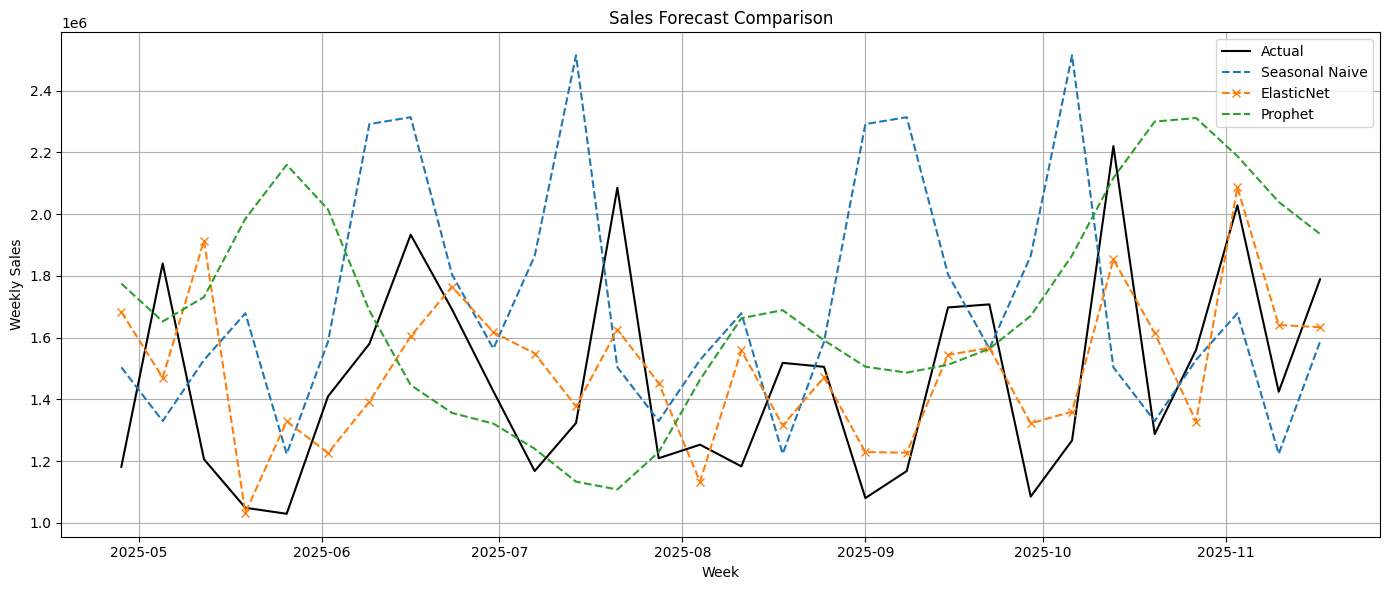

In [86]:
# Forecast vs Actual plot
plt.figure(figsize=(14,6))
plt.plot(df_test['week'], y_test, label='Actual',color='black')
plt.plot(df_test['week'], naive_preds, label='Seasonal Naive', linestyle='--')
plt.plot(df_test['week'], elastic_preds, label='ElasticNet', linestyle='--', marker='x')
plt.plot(df_test['week'], prophet_preds, label='Prophet', linestyle='--')

plt.title("Sales Forecast Comparison")
plt.xlabel("Week")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

##### Residual Analysis

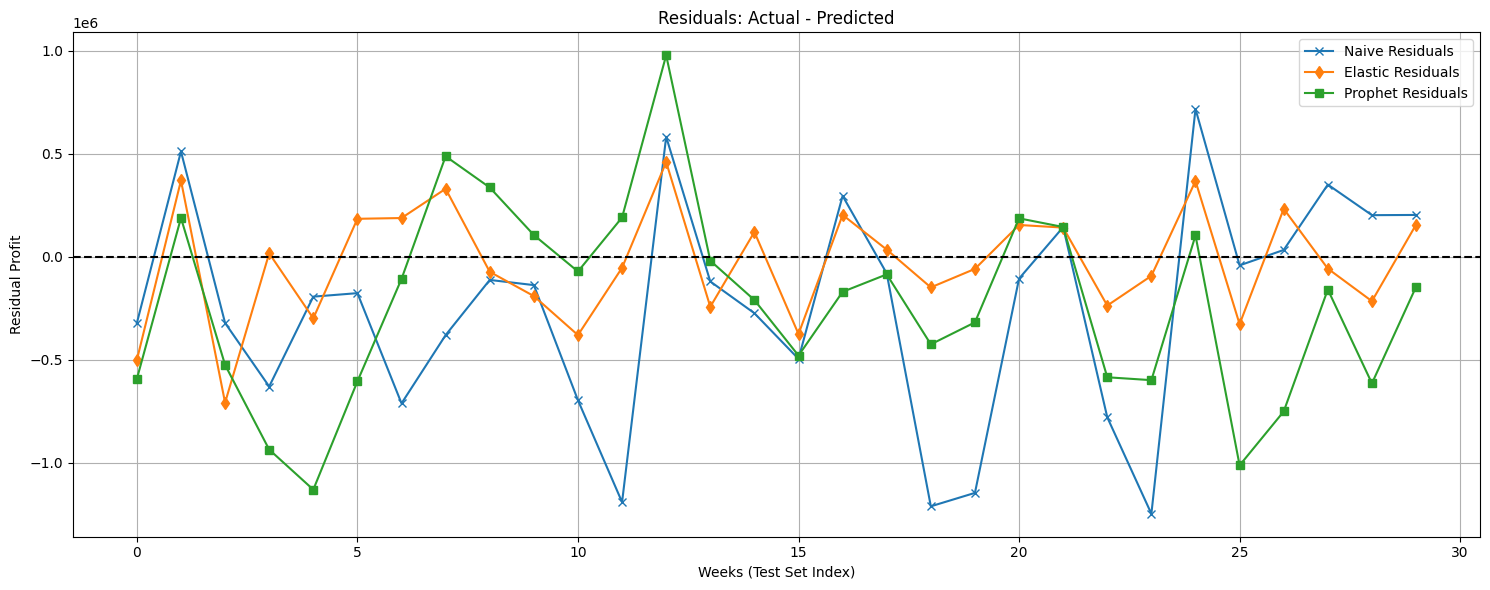

In [104]:
# Calculate residuals
naive_residuals = y_test.values - naive_preds
elastic_residuals = y_test.values - elastic_preds
prophet_residuals = y_test.values - prophet_preds

plt.figure(figsize=(15, 6))
plt.plot(naive_residuals, label='Naive Residuals', marker='x')
plt.plot(elastic_residuals, label='Elastic Residuals', marker='d')
plt.plot(prophet_residuals, label='Prophet Residuals', marker='s')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals: Actual - Predicted")
plt.xlabel("Weeks (Test Set Index)")
plt.ylabel("Residual Profit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Load Best Model

In [88]:
# Models dictionary
print("ElasticNet parameters:")
for param, value in elastic.get_params().items():
    print(f"  {param}: {value}")

ElasticNet parameters:
  alpha: 0.1
  copy_X: True
  fit_intercept: True
  l1_ratio: 0.7
  max_iter: 5000
  positive: False
  precompute: False
  random_state: None
  selection: cyclic
  tol: 0.0001
  warm_start: False


In [89]:
# Train
elastic.fit(X_train, y_train)
all_params = elastic.get_params()
# Predict
elastic_preds = elastic.predict(X_test)
# Use mlflow_log_model function
mlflow_log_model(
    model=elastic,
    model_name="ElasticNet_Latest",
    y_true=y_test,
    y_pred=elastic_preds,
    params={
        "transform": "none",
        "model_name": "ElasticNet_Latest",
        "Version": "Latest",
        "feature_count": len(features_base),
        "training_samples": len(X_train),
        "test_samples": len(X_test),
        **all_params
    }
)

ElasticNet_Latest logged to MLflow.
ElasticNet_Latest: RMSE: 277987.40 | MAE: 230608.57 | MAPE: 16.54


##### Final Model Saving

In [90]:
client = MlflowClient()

# Get champion model details
model_version = client.get_model_version_by_alias(
    name="weekly_forecaster",
    alias="champion"
)

print(f"Model Version: {model_version.version}")
print(f"Registered: {model_version.creation_timestamp}")

Model Version: 6
Registered: 1767136726492


#### 🏆 8.2 Model Explainability (Final Best Model)

##### SHAP Explainability: mean(|value|) feature importance

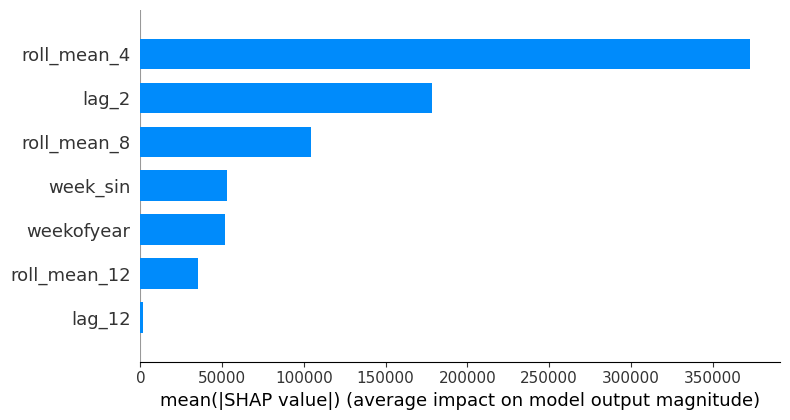

In [98]:
# Initialize SHAP explainer
# For ElasticNet (linear model) - use LinearExplainer
explainer = shap.LinearExplainer(elastic, X_train)  # Use training data
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

<ul>
        <li><strong>Most Important:</strong> roll_mean_4 (highest impact)</li>
        <li><strong>Moderate Impact:</strong> roll_mean_8 and lag_2</li>
        <li><strong>Lower Impact:</strong> week_sin, weekofyear,  roll_mean_12</li>
        <li><strong>Least Important:</strong> lag_12</li>
    </ul>
    <p><strong>Summary:</strong> Model relies heavily on trend indicators (roll_mean) and lagged data.</p>

#### 💼 8.3 Business Metrics

In [100]:
def simple_forecast_metrics(y_true, y_pred):
    """
    Simple metrics for your dashboard
    """
    print("📈 Business Metrics:\n")
    
    # 1. Percentage Error (MAPE)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"1. Average Error (MAPE): {mape:.1f}%")
    print(f"   Interpretation: On average, the forecasted values misses by about {mape:.1f}% of the actual sales.")
    print(f"   This means the forecasts is around {100-mape:.1f}% accurate.")
    
    # 2. Dollar Error
    avg_error_dinar = np.mean(np.abs(y_true - y_pred))
    avg_sales = np.mean(y_true)
    print(f"\n2. Average Error in Money (Tunisian Dinar): {avg_error_dinar:,.0f} TND")
    print(f"   Interpretation: On average, the forecast misses by about {avg_error_dinar:,.0f} TND in sales value.")
    print(f"   The average weekly sales are {avg_sales:,.0f} TND.")
    print(f"   This error represents {avg_error_dinar/avg_sales*100:.1f}% of the average weekly sales.")
    
    # 3. Improvement Compared to Simple Guess
    baseline = np.mean(y_true)  # Simply guessing average sales for all weeks
    baseline_error = np.mean(np.abs(y_true - baseline))
    
    improvement = baseline_error - avg_error_dinar
    improvement_pct = improvement / baseline_error * 100
    
    print(f"\n3.Improvement vs Simple Average Baseline Model:")
    print(f"   Baseline error (predicting average sales) is {baseline_error:,.0f} TND on average.")
    print(f"   Final model's error is {avg_error_dinar:,.0f} TND.")
    print(f"   This results in an improvement of {improvement:,.0f} TND, which is about {improvement_pct:.0f}% better than the baseline.")
    print("   The final model adds significant value compared to just guessing average sales each week.")
    
    return {
        'accuracy_percent': 100-mape,
        'avg_dinar_error': avg_error_dinar,
        'improvement_pct': improvement_pct
    }

# Usage
metrics = simple_forecast_metrics(y_test, elastic_preds)

📈 Business Metrics:

1. Average Error (MAPE): 16.5%
   Interpretation: On average, the forecasted values misses by about 16.5% of the actual sales.
   This means the forecasts is around 83.5% accurate.

2. Average Error in Money (Tunisian Dinar): 230,609 TND
   Interpretation: On average, the forecast misses by about 230,609 TND in sales value.
   The average weekly sales are 1,463,676 TND.
   This error represents 15.8% of the average weekly sales.

3.Improvement vs Simple Average Baseline Model:
   Baseline error (predicting average sales) is 275,350 TND on average.
   Final model's error is 230,609 TND.
   This results in an improvement of 44,741 TND, which is about 16% better than the baseline.
   The final model adds significant value compared to just guessing average sales each week.


##### Predict the next 12 weeks


Next 12 Weeks Forecast:
      week  predicted_profit
2025-11-24        1949333.21
2025-12-01        1828300.01
2025-12-08        1908648.31
2025-12-15        1923567.13
2025-12-22        1957230.85
2025-12-29        1691810.27
2026-01-05        1765773.07
2026-01-12        1714349.07
2026-01-19        1715506.58
2026-01-26        1700263.04
2026-02-02        1695657.38
2026-02-09        1689603.87


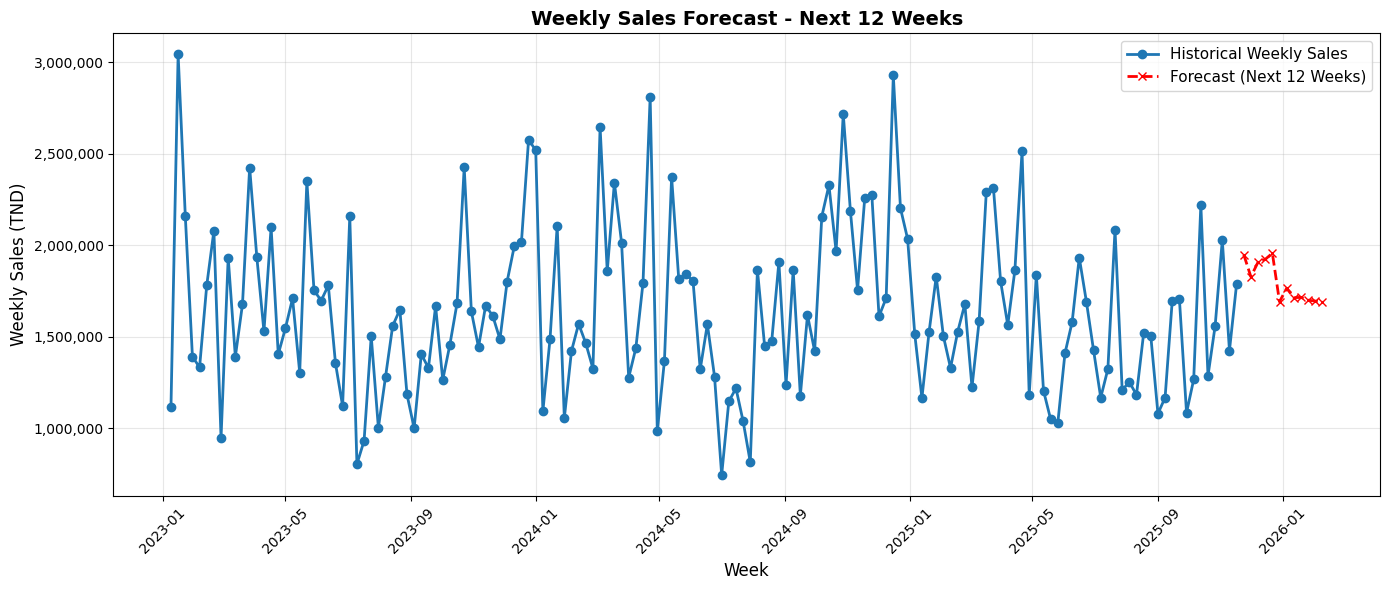


FORECAST SUMMARY
Forecast Period: 2025-11-24 to 2026-02-09
Average Weekly Forecast: TND 1,795,004
Total Forecast (12 weeks): TND 21,540,043
Minimum Forecast: TND 1,689,604
Maximum Forecast: TND 1,957,231


In [110]:
import numpy as np
import pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt

# Step 1: Prepare future dates
last_date = df_weekly['week'].max()
future_dates = [last_date + timedelta(weeks=i) for i in range(1, 13)]

# Create future dataframe
future_df = pd.DataFrame({'week': future_dates})

# Step 2: Add calendar features to future dates
future_df['weekofyear'] = future_df['week'].dt.isocalendar().week
future_df['week_sin'] = np.sin(2 * np.pi * future_df['weekofyear'] / 52.1429)

# Step 3: Rolling forecast loop
future_predictions = []
base_df = df_weekly.copy()

# Get the last values for lags and rolling means
last_2 = base_df['weekly_sales'].iloc[-2]
last_12 = base_df['weekly_sales'].iloc[-12]

# Calculate initial rolling means
roll_mean_4 = base_df['weekly_sales'].iloc[-4:].mean()
roll_mean_8 = base_df['weekly_sales'].iloc[-8:].mean()
roll_mean_12 = base_df['weekly_sales'].iloc[-12:].mean()

for i in range(12):
    row = future_df.iloc[i].copy()
    
    # Create feature dictionary
    features = {
        'weekofyear': row['weekofyear'],
        'week_sin': row['week_sin'],
        'lag_2': last_2,
        'lag_12': last_12,
        'roll_mean_4': roll_mean_4,
        'roll_mean_8': roll_mean_8,
        'roll_mean_12': roll_mean_12
    }
    
    # Convert to dataframe with correct column order
    input_features = pd.DataFrame([features])[features_base]
    
    # Predict weekly sales
    predicted_sales = elastic.predict(input_features)[0]
    
    # Store prediction
    future_predictions.append({
        'week': row['week'],
        'predicted_profit': predicted_sales
    })
    
    # Update lag values for next iteration
    last_2 = predicted_sales
    last_12 = base_df['weekly_sales'].iloc[-11] if i == 0 else base_df['weekly_sales'].iloc[-12 + i]
    
    # Update rolling means
    if i == 0:
        # First prediction: update rolling means with new prediction
        roll_mean_4 = (base_df['weekly_sales'].iloc[-3:].sum() + predicted_sales) / 4
        roll_mean_8 = (base_df['weekly_sales'].iloc[-7:].sum() + predicted_sales) / 8
        roll_mean_12 = (base_df['weekly_sales'].iloc[-11:].sum() + predicted_sales) / 12
    else:
        # For subsequent predictions, we'd need to track a window of predictions
        # For simplicity, we'll use a simple decay approach
        roll_mean_4 = (roll_mean_4 * 3 + predicted_sales) / 4
        roll_mean_8 = (roll_mean_8 * 7 + predicted_sales) / 8
        roll_mean_12 = (roll_mean_12 * 11 + predicted_sales) / 12
    
    # Add prediction to base_df for next iteration (optional)
    base_df = pd.concat([
        base_df, 
        pd.DataFrame([{'week': row['week'], 'weekly_sales': predicted_sales}])
    ], ignore_index=True)

# Step 4: Create final forecast dataframe
forecast_df = pd.DataFrame(future_predictions)
forecast_df['predicted_profit'] = forecast_df['predicted_profit'].round(2)

print("\nNext 12 Weeks Forecast:")
print(forecast_df.to_string(index=False))

# Step 5: Plot historical and forecasted sales
plt.figure(figsize=(14, 6))
plt.plot(df_weekly['week'], df_weekly['weekly_sales'], 
         label='Historical Weekly Sales', marker='o', linewidth=2)

plt.plot(forecast_df['week'], forecast_df['predicted_profit'], 
         label='Forecast (Next 12 Weeks)', linestyle='--', 
         marker='x', color='red', linewidth=2)

plt.title("Weekly Sales Forecast - Next 12 Weeks", fontsize=14, fontweight='bold')
plt.xlabel("Week", fontsize=12)
plt.ylabel("Weekly Sales (TND)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# Step 6: Print summary statistics
print("\n" + "="*50)
print("FORECAST SUMMARY")
print("="*50)
print(f"Forecast Period: {forecast_df['week'].min().date()} to {forecast_df['week'].max().date()}")
print(f"Average Weekly Forecast: TND {forecast_df['predicted_profit'].mean():,.0f}")
print(f"Total Forecast (12 weeks): TND {forecast_df['predicted_profit'].sum():,.0f}")
print(f"Minimum Forecast: TND {forecast_df['predicted_profit'].min():,.0f}")
print(f"Maximum Forecast: TND {forecast_df['predicted_profit'].max():,.0f}")